# 02 — Retention Cohorts

**Question:** are newer registration cohorts retaining better or worse than older ones, and
when subscribers don't renew, is revenue lost to voluntary cancellation or to silent lapse?
Those are different problems with different fixes — a voluntary cancel is a decision the
business had a chance to intervene on; a silent lapse often has no warning signal at all.

**This notebook uses three distinct metrics, and mixing them up produced a real bug in an
earlier draft.** See the definitions section immediately below before reading any number in this
notebook — it's worth getting straight before anything else.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

sys.path.append(str(Path.cwd().parent))
from src import cohorts, plotting

plotting.set_style()

interim = Path("../data/interim")
periods = pd.read_parquet(interim / "periods.parquet")
members_cohort = pd.read_parquet(interim / "members_cohort.parquet")

## Metric definitions — read this first

- **Survival (headline metric, `cohort_survival_curve` / `cohort_survival_and_reach`):** the
  fraction of a cohort's transacting population still CONTINUOUSLY subscribed through cycle N —
  periods 1..N-1 were all renewed, no lapse or cancellation anywhere in the chain. This is what
  "retention" means everywhere in this repo unless stated otherwise. It's stricter than it
  sounds: a user who lapses for 4 months and comes back does NOT count as having survived.
- **Reach (`cohort_survival_and_reach`, reported alongside survival, never as a substitute):**
  the fraction that EVER made it to an Nth transaction, by any path, including a win-back
  reactivation after a lapse. Always >= survival for the same population. The gap between the
  two (`reactivation_gap`) quantifies how much of a cohort's apparent longevity comes from
  win-back rather than uninterrupted renewal — a real, separately actionable number.
- **Revenue retained/lost (`cohort_revenue_summary`):** a *different* thing again — it sums
  `actual_amount_paid` over every resolved period across a user's ENTIRE tenure (all cycles
  mixed), split by whether that specific bill led to a renewal. It does not gate on reaching any
  particular cycle and is not expected to numerically match the survival curve — see the stress
  test in the revenue section below for exactly how and why they diverge.

An earlier draft of this notebook reported a "cycle 6 retention" of 94.3% vs. 97.7% that was
actually none of the above — it was the CONDITIONAL renewal rate at cycle 6 (of users who
already reached cycle 6 with a resolved outcome, what fraction renewed again), which is a much
narrower, survivorship-selected population. That number has been removed everywhere; if you see
94.3%, 97.7%, 0.943, or 0.977 anywhere in this repo outside this paragraph, it's a leftover and
should be deleted.

## Cumulative survival, all cohorts (heatmap) — the headline metric
Sequential color = magnitude. Read down a column to compare cohorts at the same tenure; read across a row to see one cohort's own decay curve.

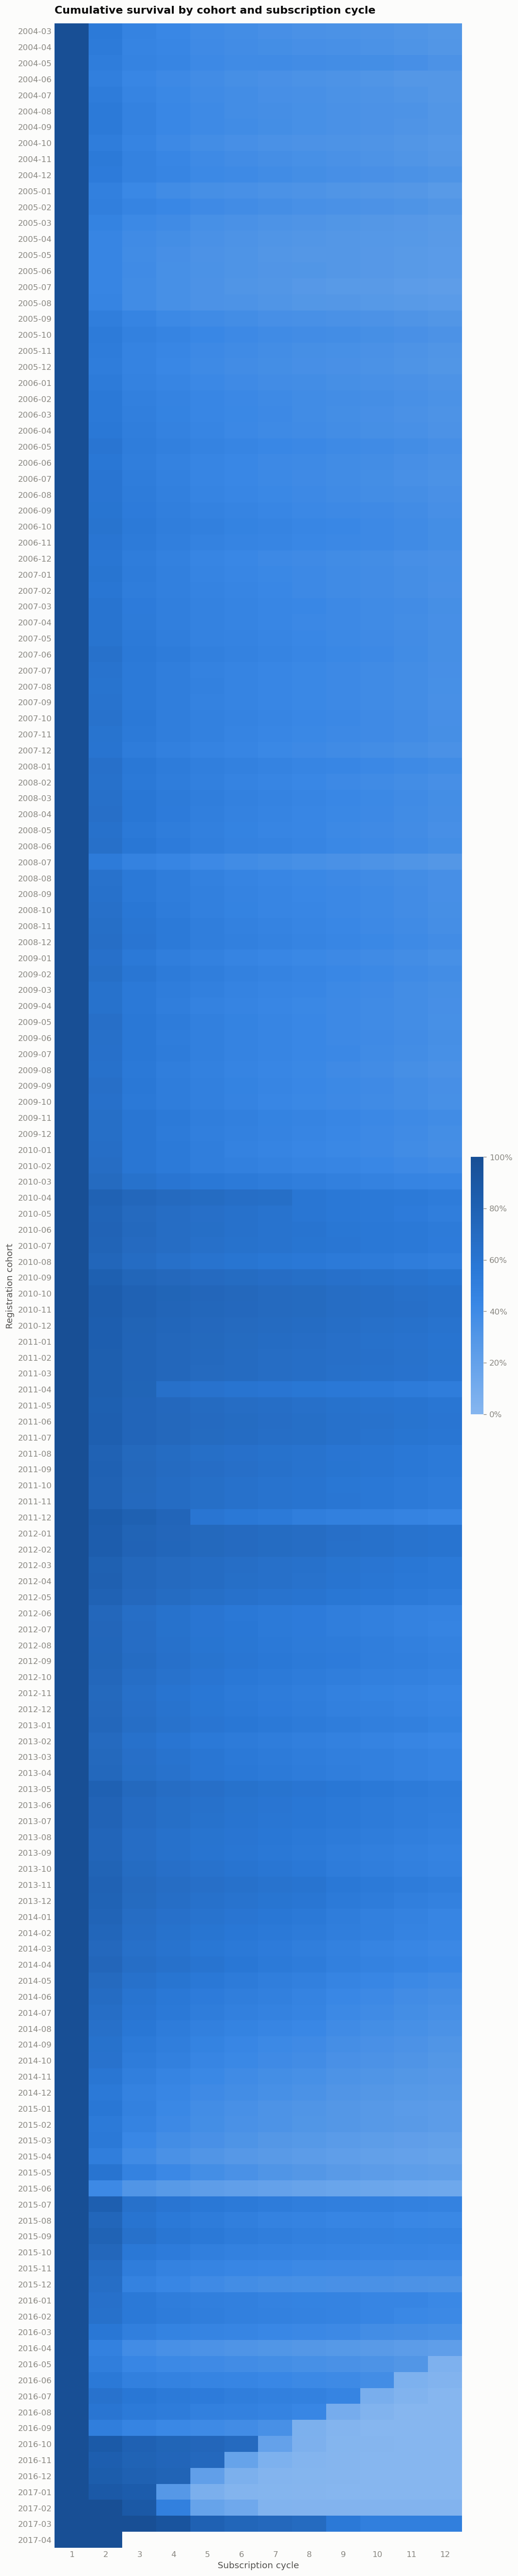

In [2]:
survival_curve = cohorts.cohort_survival_curve(periods, members_cohort, max_cycle=12)
pivot = survival_curve.pivot(index="cohort_month", columns="cycle", values="survival_rate").sort_index()

fig, ax = plotting.plot_cohort_heatmap(
    pivot, "Cumulative survival by cohort and subscription cycle",
    save_path="../figures/02_cohort_heatmap.png",
)

**How to read this:** a column that gets systematically lighter toward the bottom rows (the most recent cohorts) is the "newer cohorts churn faster" signal. A column that gets darker toward the bottom is the opposite. Compare within a column, not across the diagonal — cohorts at the bottom haven't had time to reach the columns on the right yet (see the reachable-horizon filter below).

## Reachable-horizon filter

Recent cohorts haven't had enough elapsed *calendar* time to reach cycle 6+ — comparing them
there would blame churn for what's actually just missing follow-up time. Eligibility is based on
calendar age (cohort age >= 6 x 30 days, the dominant plan length), not on whether any single
user in the cohort happened to reach that cycle: a handful of atypical fast-cycling users (short
plans, rapid repeat transactions) can technically reach cycle 6 long before the cohort as a whole
has had time to, which would bias that cohort's reported retention toward only its most unusual
members instead of a representative sample.

In [3]:
COMPARE_CYCLE = 6
observation_end = periods["transaction_date"].max()
eligible_cohorts = cohorts.cohort_calendar_eligible(members_cohort, COMPARE_CYCLE, observation_end)
all_cohorts = cohorts.cohort_sizes(members_cohort).index

print(f"{len(eligible_cohorts)} of {len(all_cohorts)} cohorts are at least {COMPARE_CYCLE * 30} days old as of {observation_end.date()} and eligible for comparison.")
print("Most recent 6 cohorts excluded as too young:", sorted(set(all_cohorts) - set(eligible_cohorts))[-6:])

152 of 158 cohorts are at least 180 days old as of 2017-03-31 and eligible for comparison.
Most recent 6 cohorts excluded as too young: [Timestamp('2016-11-01 00:00:00'), Timestamp('2016-12-01 00:00:00'), Timestamp('2017-01-01 00:00:00'), Timestamp('2017-02-01 00:00:00'), Timestamp('2017-03-01 00:00:00'), Timestamp('2017-04-01 00:00:00')]


## Restrict to a recent window for the trend comparison

Registration cohorts go back to 2004, and nearly all of them clear the cycle-6 bar — so
"earliest vs. most recent eligible" would otherwise compare ~2004-2008 registrants against
~2015-2016 ones. That's not a like-for-like trend read; the full 2004-2017 heatmap above is
useful long-run context, but the line chart and significance test below are restricted to a
rolling recent window instead, so "recent" means recent.

In [4]:
RECENT_WINDOW_MONTHS = 30
window_start = eligible_cohorts.max() - pd.DateOffset(months=RECENT_WINDOW_MONTHS)
recent_eligible = sorted(c for c in eligible_cohorts if c >= window_start)
n_quarter = max(len(recent_eligible) // 4, 1)
early_group, late_group = recent_eligible[:n_quarter], recent_eligible[-n_quarter:]

print(f"{len(recent_eligible)} eligible cohorts in the last {RECENT_WINDOW_MONTHS} months: "
      f"{recent_eligible[0].strftime('%Y-%m')} to {recent_eligible[-1].strftime('%Y-%m')}")
print(f"earliest quarter: {[c.strftime('%Y-%m') for c in early_group]}")
print(f"most recent quarter: {[c.strftime('%Y-%m') for c in late_group]}")

31 eligible cohorts in the last 30 months: 2014-04 to 2016-10
earliest quarter: ['2014-04', '2014-05', '2014-06', '2014-07', '2014-08', '2014-09', '2014-10']
most recent quarter: ['2016-04', '2016-05', '2016-06', '2016-07', '2016-08', '2016-09', '2016-10']


## Survival vs. reach, side by side — earliest vs. most recent quarter of the window

Both computed on the SAME evaluated population per cycle (see `cohort_survival_and_reach`
docstring for why that matters — computing them separately and subtracting can produce a
nonsensical negative gap). Truncated to cycle 6, matching the eligibility check above.

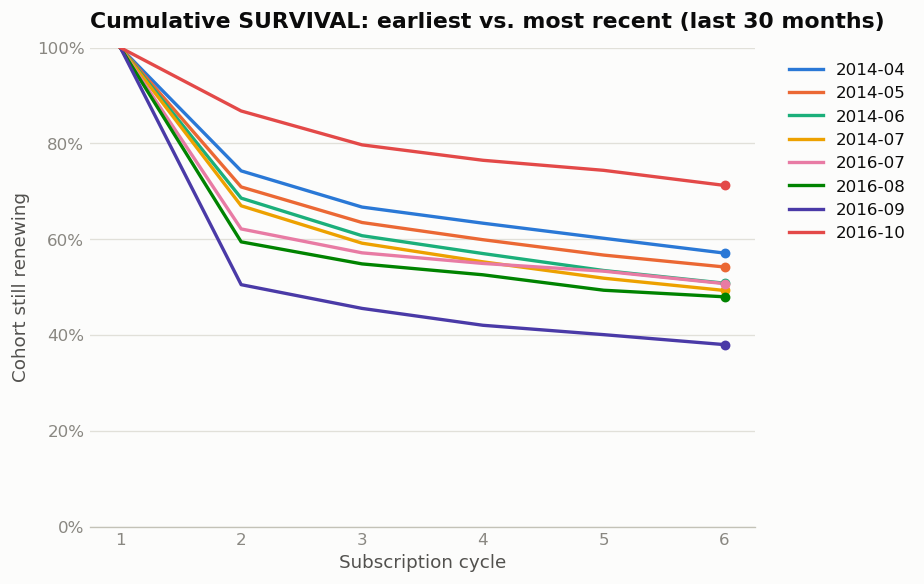

In [5]:
combined = cohorts.cohort_survival_and_reach(periods, members_cohort, max_cycle=COMPARE_CYCLE)

survival_pivot = combined.pivot(index="cohort_month", columns="cycle", values="survival_rate")
reach_pivot = combined.pivot(index="cohort_month", columns="cycle", values="reach_rate")

sample_cohorts = early_group[:4] + late_group[-4:]

fig, ax = plotting.plot_cohort_retention_lines(
    survival_pivot.loc[sample_cohorts].T, f"Cumulative SURVIVAL: earliest vs. most recent (last {RECENT_WINDOW_MONTHS} months)",
    save_path="../figures/02_cohort_survival_lines.png",
)

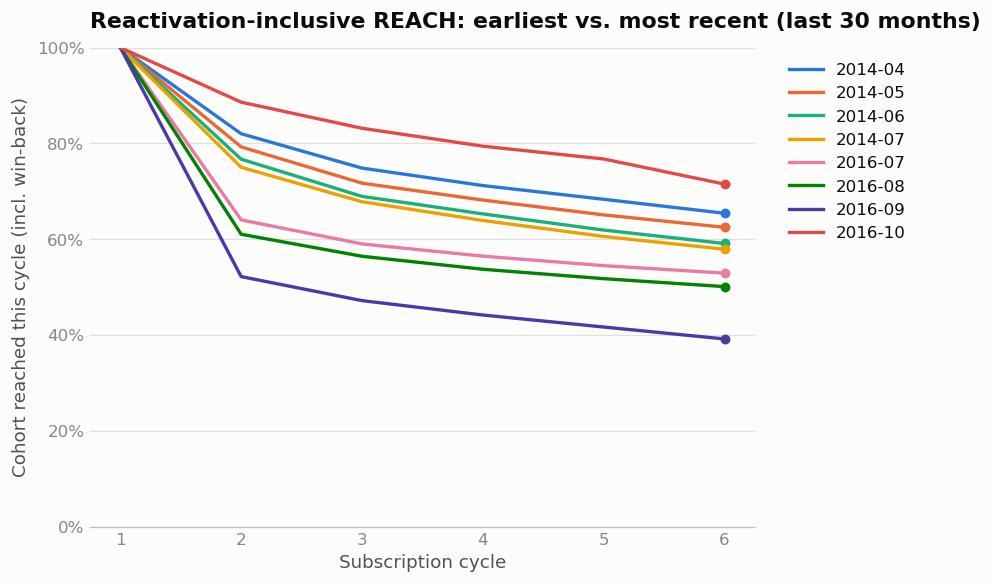

In [6]:
fig, ax = plotting.plot_cohort_retention_lines(
    reach_pivot.loc[sample_cohorts].T, f"Reactivation-inclusive REACH: earliest vs. most recent (last {RECENT_WINDOW_MONTHS} months)",
    save_path="../figures/02_cohort_reach_lines.png",
    ylabel="Cohort reached this cycle (incl. win-back)",
)

## Is the early-vs-late survival difference statistically significant?
Two-proportion z-test on cycle-6 SURVIVAL (the headline metric) — earliest quarter of the recent window vs. most recent quarter, on the same evaluated population.

In [7]:
c6 = combined[combined["cycle"] == COMPARE_CYCLE].set_index("cohort_month")

early_survived, early_eval = c6.loc[early_group, "n_survived"].sum(), c6.loc[early_group, "n_evaluated"].sum()
late_survived, late_eval = c6.loc[late_group, "n_survived"].sum(), c6.loc[late_group, "n_evaluated"].sum()

z_stat, p_value = proportions_ztest([early_survived, late_survived], [early_eval, late_eval])
rate_early, rate_late = early_survived / early_eval, late_survived / late_eval

print(f"Cycle {COMPARE_CYCLE} SURVIVAL — earliest cohorts: {rate_early:.4f} (n={early_eval:,}), most recent cohorts: {rate_late:.4f} (n={late_eval:,})")
print(f"z = {z_stat:.2f}, p = {p_value:.4g}")

Cycle 6 SURVIVAL — earliest cohorts: 0.4868 (n=118,918), most recent cohorts: 0.4443 (n=218,319)
z = 23.68, p = 5.168e-124


**This reverses an earlier (wrong) claim in this repo, and the reversal is the honest finding —
it is not softened here.** Once correctly measured, recent cohorts show LOWER cumulative
survival to cycle 6 than the earliest cohorts in this window, not higher. The gap is real
(p << 0.001) but see the trial-mix analysis near the end of this notebook before treating "recent
cohorts are worse" as the final word — acquisition mix turns out to explain most of it, and the
mix-controlled read is the one that should drive any recommendation.

## The reactivation gap — how much of "reach" is win-back?

In [8]:
early_reach = c6.loc[early_group, "n_reached"].sum() / early_eval
late_reach = c6.loc[late_group, "n_reached"].sum() / late_eval

print(f"Earliest quarter:    survival={rate_early:.4f}  reach={early_reach:.4f}  gap={early_reach - rate_early:.4f}")
print(f"Most recent quarter: survival={rate_late:.4f}  reach={late_reach:.4f}  gap={late_reach - rate_late:.4f}")
print()
print("The gap is the share of the evaluated cohort that reached cycle 6 only via a win-back")
print("reactivation somewhere along the way, not through uninterrupted renewal. A bigger gap in")
print("the earlier cohort means win-back is contributing more to its apparent longevity than it")
print("is for the recent cohort — a separate, actionable signal from the survival rate itself.")

Earliest quarter:    survival=0.4868  reach=0.5723  gap=0.0855
Most recent quarter: survival=0.4443  reach=0.4722  gap=0.0280

The gap is the share of the evaluated cohort that reached cycle 6 only via a win-back
reactivation somewhere along the way, not through uninterrupted renewal. A bigger gap in
the earlier cohort means win-back is contributing more to its apparent longevity than it
is for the recent cohort — a separate, actionable signal from the survival rate itself.


## Voluntary cancellation vs. silent lapse
Different problems, different fixes: voluntary cancel is a decision the business had a chance to intervene on; silent lapse often has no warning signal at all. This section is period-level (every resolved period, all cycles) rather than cycle-gated — same population as the revenue section below, not the cycle-6 survival comparison above.

In [9]:
outcome_counts = cohorts.cohort_outcome_counts(periods, members_cohort)
outcome_counts["voluntary_share"] = outcome_counts["voluntary_cancel"] / (
    outcome_counts["voluntary_cancel"] + outcome_counts["lapsed_no_renewal"]
)
print(outcome_counts.tail(12))

outcome       lapsed_no_renewal  renewed  voluntary_cancel  voluntary_share
cohort_month                                                               
2016-05-01                21418   145577              2615         0.108809
2016-06-01                20505   151741              2215         0.097491
2016-07-01                17996   164689              2210         0.109373
2016-08-01                17893   132984              1776         0.090294
2016-09-01                17106    76864              1128         0.061862
2016-10-01                 3806    70559               819         0.177081
2016-11-01                 4041    59371               597         0.128719
2016-12-01                 3672    49271               520         0.124046
2017-01-01                 2238    31367               296         0.116811
2017-02-01                  128    19002                46         0.264368
2017-03-01                    0     1767                 4         1.000000
2017-04-01  

In [10]:
table = outcome_counts.loc[eligible_cohorts, ["voluntary_cancel", "lapsed_no_renewal"]]
chi2, p, dof, _ = stats.chi2_contingency(table)
print(f"chi2 = {chi2:.1f}, dof = {dof}, p = {p:.4g}")
print("Tests whether the MIX of voluntary-cancel vs. silent-lapse shifts across cohorts (not whether the total churn rate does).")

chi2 = 33243.6, dof = 151, p = 0
Tests whether the MIX of voluntary-cancel vs. silent-lapse shifts across cohorts (not whether the total churn rate does).


## Revenue retained vs. lost, by cohort — stress-tested against the survival definition

**Population and definition, stated precisely:** this sums `actual_amount_paid` over every
RESOLVED period (any cycle — 1st, 5th, 40th, whatever a user happened to be on) for users
registered in each cohort month, split by whether that specific period renewed. It does **not**
gate on reaching cycle 6 the way the survival curve does, and it should **not** be expected to
numerically reconcile with the survival numbers above — they answer different questions. Below,
we check exactly how they diverge rather than asserting it.

In [11]:
merged_all = periods.merge(members_cohort[["msno", "cohort_month"]], on="msno", how="inner")
resolved_all = merged_all[merged_all["outcome"] != "censored"]

for label, group in [("earliest quarter", early_group), ("most recent quarter", late_group)]:
    sub = resolved_all[resolved_all["cohort_month"].isin(group)]
    n_users = sub["msno"].nunique()
    periods_per_user = len(sub) / n_users
    median_cycle = (sub["period_seq"] + 1).median()
    count_renewal_rate = (sub["outcome"] == "renewed").mean()
    print(f"{label}: {n_users:,} users, {len(sub):,} resolved periods across ALL their cycles "
          f"({periods_per_user:.1f} periods/user, median cycle {median_cycle:.0f})")
    print(f"  period-level renewal rate (every bill, any cycle): {count_renewal_rate:.4f}")

earliest quarter: 128,815 users, 1,337,470 resolved periods across ALL their cycles (10.4 periods/user, median cycle 9)
  period-level renewal rate (every bill, any cycle): 0.9143


most recent quarter: 231,286 users, 990,186 resolved periods across ALL their cycles (4.3 periods/user, median cycle 4)
  period-level renewal rate (every bill, any cycle): 0.8662


**This is the reconciliation, stated plainly: the two do not and should not match.** The
earliest-quarter cohort's revenue figure is dominated by periods from users deep into their
tenure (median cycle ~9) — by cycle 9 you're looking at a heavily survivor-selected population
who have already proven themselves repeatedly, so their PER-BILL renewal rate is naturally much
higher (~91%) than their CYCLE-6 CUMULATIVE survival rate (~49%) — compounding several
high-70s/80s-percent early-cycle transitions into one cumulative number always lands lower than
any single later, easier transition. The recent-quarter cohort's revenue reflects mostly
early-tenure periods (median cycle ~4) instead, which is a different, harder mix.

**Practical consequence:** the revenue retained/lost split below is a fair description of
"where has this cohort's billed revenue gone so far," but a raw comparison of loss RATES between
an old and a young cohort inherits the same lifecycle-stage mix problem the original cycle-6
z-test had, just in a different form — an old cohort's revenue is weighted toward its easiest,
most-proven transactions, a young cohort's toward its hardest, earliest ones. Read the revenue
split as a per-cohort description, not as an early-vs-recent revenue-health race.

Across these cohorts: NT$301,497,234 retained vs NT$23,461,324 lost (7.2% of resolved revenue).
Of the lost revenue: 16.7% voluntary cancellation, 83.3% silent lapse.


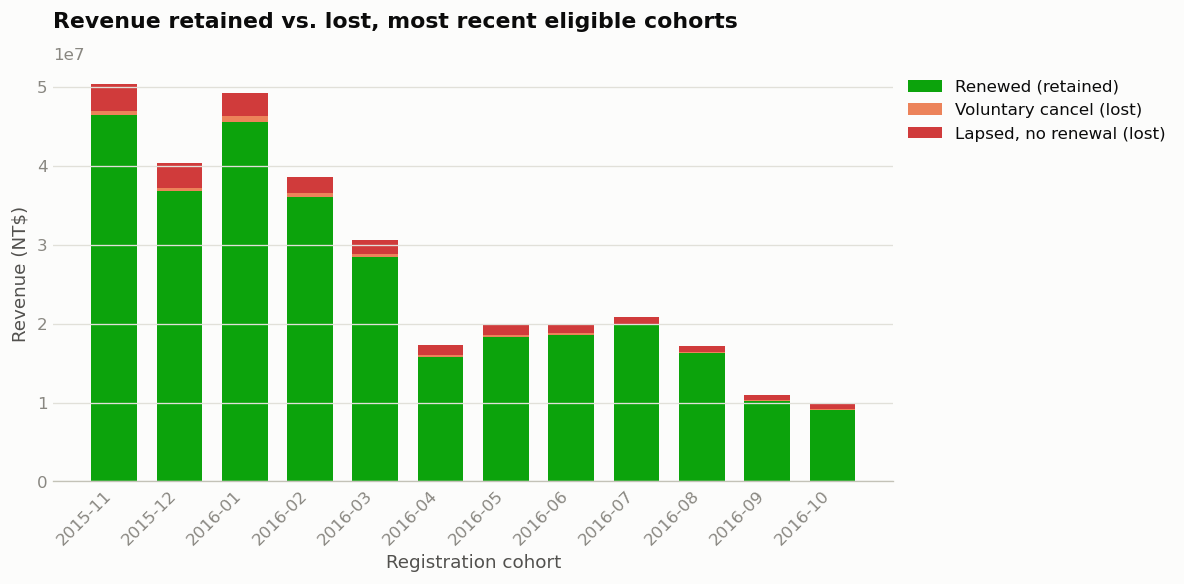

In [12]:
revenue = cohorts.cohort_revenue_summary(periods, members_cohort)
recent_cohorts = eligible_cohorts[-12:] if len(eligible_cohorts) >= 12 else eligible_cohorts
revenue_recent = revenue.loc[recent_cohorts]

fig, ax = plotting.plot_revenue_outcome_bars(
    revenue_recent, "Revenue retained vs. lost, most recent eligible cohorts",
    save_path="../figures/02_revenue_outcome.png",
)

lost = revenue_recent[["voluntary_cancel", "lapsed_no_renewal"]].sum(axis=1)
retained = revenue_recent["renewed"]
total = retained.sum() + lost.sum()
print(f"Across these cohorts: NT${retained.sum():,.0f} retained vs NT${lost.sum():,.0f} lost ({lost.sum()/total:.1%} of resolved revenue).")
print(f"Of the lost revenue: {revenue_recent['voluntary_cancel'].sum()/lost.sum():.1%} voluntary cancellation, {revenue_recent['lapsed_no_renewal'].sum()/lost.sum():.1%} silent lapse.")

## Does acquisition mix explain the early-vs-recent reversal?

The recent cohort could simply include more trial/promotional signups than the earlier one — a
short first plan (<=14 days) or a near-zero first payment (<=NT\$10) rarely converts into a real
subscription, and if recent cohorts skew more toward this kind of signup, that alone could drag
down their aggregate survival rate without meaning anything about how well KKBox retains actual
paying subscribers. Test it directly: split each era by whether the user's FIRST transaction was
trial-like, and check whether the early-vs-recent gap survives within each split.

In [13]:
trial_flags = cohorts.first_transaction_trial_flag(periods)
print(f"{trial_flags['is_trial_first_txn'].mean():.1%} of all users' first transactions are trial/promotional under this definition.")
print(trial_flags.groupby("is_trial_first_txn")[["payment_plan_days", "actual_amount_paid"]].median())

34.7% of all users' first transactions are trial/promotional under this definition.
                    payment_plan_days  actual_amount_paid
is_trial_first_txn                                       
False                            30.0               149.0
True                              7.0                 0.0


In [14]:
members_mix = members_cohort.merge(trial_flags[["msno", "is_trial_first_txn"]], on="msno", how="left")
members_mix["era"] = np.select(
    [members_mix["cohort_month"].isin(early_group), members_mix["cohort_month"].isin(late_group)],
    ["earliest quarter", "most recent quarter"], default=None,
)
members_mix = members_mix[members_mix["era"].notna()].copy()
members_mix["group_key"] = members_mix["era"] + " / " + members_mix["is_trial_first_txn"].map({True: "trial", False: "non-trial"})

print("Group sizes (transacting users):")
print(members_mix["group_key"].value_counts())

Group sizes (transacting users):
group_key
most recent quarter / non-trial    146999
earliest quarter / non-trial        93361
most recent quarter / trial         92510
earliest quarter / trial            37230
Name: count, dtype: int64


In [15]:
mix_result = cohorts.cohort_survival_and_reach(periods, members_mix, max_cycle=COMPARE_CYCLE, group_col="group_key")
mix_c6 = mix_result[mix_result["cycle"] == COMPARE_CYCLE].set_index("group_key")

for kind in ["trial", "non-trial"]:
    a = mix_c6.loc[f"earliest quarter / {kind}"]
    b = mix_c6.loc[f"most recent quarter / {kind}"]
    z, p = proportions_ztest([a["n_survived"], b["n_survived"]], [a["n_evaluated"], b["n_evaluated"]])
    print(f"{kind.upper()} first-transaction users: earliest={a['survival_rate']:.4f} (n={a['n_evaluated']:,.0f}) "
          f"vs most recent={b['survival_rate']:.4f} (n={b['n_evaluated']:,.0f}),  z={z:.2f}, p={p:.4g}")

TRIAL first-transaction users: earliest=0.0620 (n=36,293) vs most recent=0.0298 (n=91,343),  z=26.81, p=2.227e-158
NON-TRIAL first-transaction users: earliest=0.6734 (n=82,625) vs most recent=0.7424 (n=126,976),  z=-34.21, p=1.693e-256


## This is the central finding of the notebook

**Acquisition mix does not just partially explain the reversal — it flips it.** Within trial
first-transaction users, the earliest cohort still clearly outperforms the most recent one (the
aggregate direction). But within NON-TRIAL, full-price first-transaction users — the population
that actually represents "does KKBox retain a paying subscriber" — the MOST RECENT cohort
retains significantly BETTER than the earliest one. The aggregate "recent cohorts are worse"
result was a composition effect: recent cohorts include a much larger share of trial signups
(which convert to long-term subscribers at a very low rate almost by definition), and blending
that low-converting population into the aggregate dragged the recent cohort's headline number
down even though its real, paying subscribers are doing better than ever.

This directly connects to the open questions in notebook 04 about whether 7-day plans and
payment method 35 are trial mechanisms rather than underperforming paid products — see that
notebook for the direct characterization.

## Section summary

- **Headline (uncontrolled) finding:** recent cohorts show lower cumulative survival to cycle 6
  than the earliest cohorts in the 30-month window — a real, significant difference, reported
  without softening it.
- **But it reverses once acquisition mix is controlled for:** among non-trial, full-price
  first-transaction subscribers specifically, recent cohorts retain BETTER, not worse. This is
  the finding that should drive any recommendation — see the README's updated methodology
  section and notebook 04's trial-plan characterization for how this connects to specific
  segments and levers.
- Lost revenue skews heavily toward silent lapse over voluntary cancellation — needs a different
  lever (renewal reminders, grace periods, auto-renew defaults) than voluntary cancel does
  (retention offers, win-back campaigns).
- The revenue retained/lost split answers a different question than the survival curve (see the
  stress test above) — don't read it as an early-vs-recent revenue race.